# per-residue attribution task

In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from joblib import Parallel, delayed
import os, glob, joblib, gc, esm , torch, ast, numpy as np, pandas as pd

In [2]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score
from scipy.stats import randint, uniform

## select protein-coding gene

In [3]:
gene_name='inhA'
# pick the reference CDS protein sequence
ref_seqs=pd.read_csv('./data/catalog/protein_sequences.csv')
ref_protein = ref_seqs.loc[ref_seqs['gene'] == gene_name, 'protein_sequence'].values

In [4]:
#load the gene sequence file
gene_sequences=pd.read_csv(f"./data/sequence_data_csv/{gene_name}_combined_sequence_data.csv")
gene_sequences_filtered = gene_sequences[gene_sequences["Frameshift_Mutation"] == 0].copy()
# Ensure required columns exist
if "Protein_Sequence" not in gene_sequences_filtered.columns:
    raise ValueError("CSV file must contain a 'Protein_Sequence' column.")

## load pretrained model

In [5]:
# Assuming Random Forest performed best and saved
model_names = ["rf", "svr", "knn"]
model_paths = {
    "rf":  f"./trained_models/{gene_name}_best_rf_model.joblib",
    "svr": f"./trained_models/{gene_name}_best_svr_model.joblib",
    "knn": f"./trained_models/{gene_name}_best_knn_model.joblib"
}


In [7]:
#since three models use same embedding - no need to compute baseline preds thrice
model = joblib.load(f"./trained_models/{gene_name}_best_rf_model.joblib")
mean_glob   = f"embeddings/{gene_name}/mean/{gene_name}_mean_chunk_*.npz"
out_dir     = f"baseline_preds/{gene_name}_base_preds_chunks"
os.makedirs(out_dir, exist_ok=True)

mean_paths  = sorted(glob.glob(mean_glob))

total = 0
for path in tqdm(mean_paths, desc="baseline preds"):
    z       = np.load(path)                           # identifier, mean_embedding
    X_mean  = z["mean_embedding"]                     # (n_i, 320)
    preds   = model.predict(X_mean).astype("float32")

    chunk_id = os.path.basename(path).split("_")[-1].split(".")[0]
    np.save(f"{out_dir}/base_preds_chunk_{chunk_id}.npy", preds)

    total += len(preds)

print("baseline predictions written for", total, "sequences")


baseline preds: 100%|██████████| 16/16 [00:00<00:00, 31.14it/s]

baseline predictions written for 15166 sequences


In [8]:
import numpy as np, glob

tok_paths = sorted(glob.glob(f"./embeddings/{gene_name}/token/{gene_name}_tok_chunk_*.npz"))

#check all sequences and select max length as seq len
seq_len = 0 
for p in tok_paths: 
    with np.load(p, allow_pickle=True) as z: 
        seq_len = max(seq_len, max(t.shape[0] for t in z["tokens"]))

# embed_dim is always 320 for ESM‑2 T6
embed_dim = 320
print("seq_len =", seq_len)

#sanity check
assert all(
    all(t.shape[0] in {seq_len, seq_len-1} for t in np.load(p, allow_pickle=True)["tokens"])
    for p in tok_paths
), "Found a sequence longer than expected — adjust seq_len!"



seq_len = 269


In [9]:

tok_glob   = f"./embeddings/{gene_name}/token/{gene_name}_tok_chunk_*.npz"
# ------------------------------------------------------------------
# 1) Collect chunk paths
# ------------------------------------------------------------------
tok_paths = sorted(glob.glob(tok_glob))
assert tok_paths, "No *_tok_chunk_*.npz files found"

with np.load(tok_paths[0], mmap_mode="r") as z0:
    seq_len = z0["tokens"].shape[1]
inv = 1.0 / (seq_len - 1)
print(f"L (padded length) = {seq_len}")

# ------------------------------------------------------------------
# 2) Load mean-pools & base predictions
# ------------------------------------------------------------------
mean_pools, base_preds, chunk_sizes = [], [], []
print("loading baseline predictions …")
for tok_p in tqdm(tok_paths):
    with np.load(tok_p, mmap_mode="r") as z:
        toks = z["tokens"]
        mp = toks.mean(axis=1, dtype=np.float32)

    chunk_id = os.path.basename(tok_p).split("_")[-1].split(".")[0]
    pred_path = f"baseline_preds/{gene_name}_base_preds_chunks/base_preds_chunk_{chunk_id}.npy"
    preds = np.load(pred_path, mmap_mode="r")

    mean_pools.append(mp)
    base_preds.append(preds.astype(np.float32))
    chunk_sizes.append(len(preds))

N_total = int(np.sum(chunk_sizes))
print("Total sequences:", N_total)

L (padded length) = 269
loading baseline predictions …


100%|██████████| 16/16 [00:35<00:00,  2.22s/it]

Total sequences: 15166


In [10]:
# ------------------------------------------------------------------
# 3) LOO Importance Calculation (one residue)
# ------------------------------------------------------------------
def importance_for_residue(res_idx: int) -> float:
    abs_sum = 0.0
    for tok_p in tok_paths:
        chunk_id = os.path.basename(tok_p).split("_")[-1].split(".")[0]
        base_path = f"baseline_preds/{gene_name}_base_preds_chunks/base_preds_chunk_{chunk_id}.npy"
        base_preds = np.load(base_path, mmap_mode="r")

        with np.load(tok_p, mmap_mode="r") as z:
            toks = z["tokens"]
            mp   = toks.mean(axis=1, dtype=np.float32)
            rvec = toks[:, res_idx, :]
            masked = (seq_len * mp - rvec) * inv

        preds_masked = model.predict(masked)
        abs_sum += np.abs(base_preds - preds_masked).sum(dtype=np.float64)

        del base_preds, mp, rvec, masked, preds_masked, toks
        gc.collect()

    return abs_sum / N_total


In [11]:
# ------------------------------------------------------------------
# CONFIG
# # ------------------------------------------------------------------

n_jobs     = 4
BATCH_SIZE = 10  # adjust as needed (10–20 is often good)
model.named_steps["model"].n_jobs = -1  # enable internal RF parallelism

In [13]:
def plot_global_importance(residue_importance_df, model_tag):
    plt.figure(figsize=(15, 5))
    plt.bar(residue_importance_df["Residue_Position"], residue_importance_df["Importance"], color='skyblue')
    plt.xlabel("Residue Position")
    plt.ylabel("Global Importance Score")
    plt.title(f"Global Residue Importance (All Chunks) for {gene_name}")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"residue_importance/{gene_name}_{model_tag}global_residue_importance.png")
    plt.show()


LOO (knn):  37%|███▋      | 10/27 [17:51<30:32, 107.78s/it]

Saved up to residue 99 → residue_importance/inhA_knn_residue_importances_loo.npy


LOO (knn):  41%|████      | 11/27 [19:53<29:55, 112.19s/it]

Saved up to residue 109 → residue_importance/inhA_knn_residue_importances_loo.npy


LOO (knn):  44%|████▍     | 12/27 [21:40<27:38, 110.58s/it]

...

Saved up to residue 249 → residue_importance/inhA_knn_residue_importances_loo.npy


LOO (knn):  96%|█████████▋| 26/27 [44:04<01:39, 99.79s/it] 

Saved up to residue 259 → residue_importance/inhA_knn_residue_importances_loo.npy


LOO (knn): 100%|██████████| 27/27 [45:34<00:00, 101.29s/it]

Saved up to residue 268 → residue_importance/inhA_knn_residue_importances_loo.npy
Residue importance saved for KNN model to: residue_importance/inhA_knn_global_residue_importance_all_chunks.csv


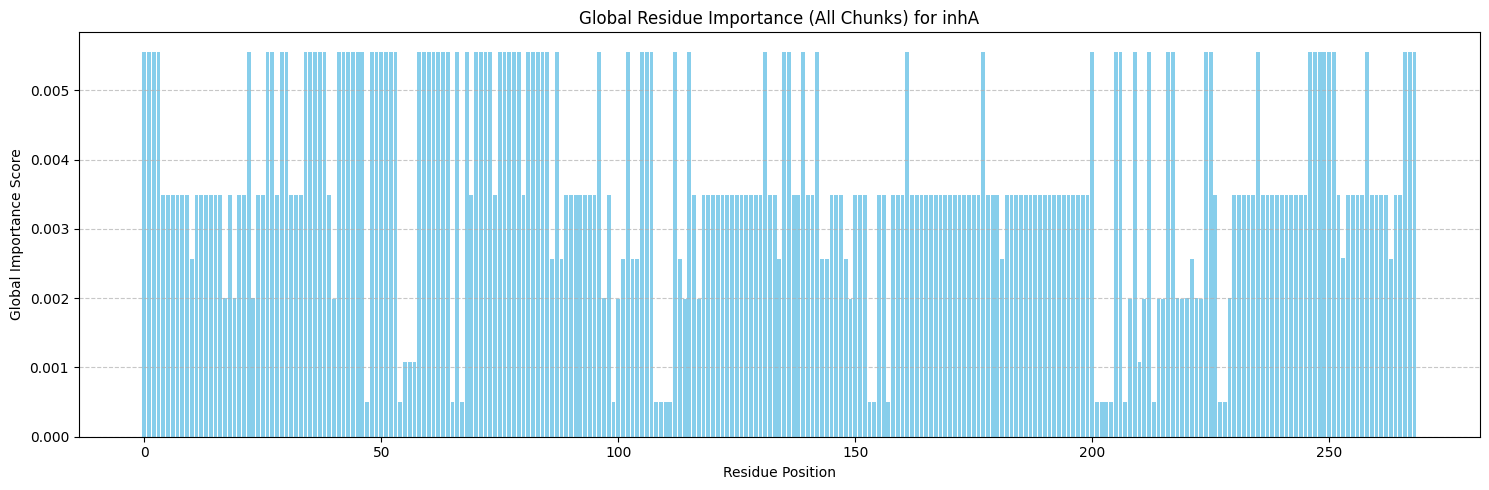

In [15]:
#residue importance for all three saved models 
from joblib import load
for model_tag in model_names:
    print(f"\nRunning importance for {model_tag.upper()} model")
    
    model = load(model_paths[model_tag])
    model.named_steps["model"].n_jobs = -1 if hasattr(model.named_steps["model"], "n_jobs") else None
    
    # Output path specific to model
    out_path = f"residue_importance/{gene_name}_{model_tag}_residue_importances_loo.npy"
    csv_path = f"residue_importance/{gene_name}_{model_tag}_global_residue_importance_all_chunks.csv"

    # Resume logic
    if os.path.exists(out_path):
        residue_importances = np.load(out_path).tolist()
        start_idx = len(residue_importances)
        print(f"Resuming from residue {start_idx}")
    else:
        residue_importances = []
        start_idx = 0

    for start in tqdm(range(start_idx, seq_len, BATCH_SIZE), desc=f"LOO ({model_tag})"):
        end = min(start + BATCH_SIZE, seq_len)

        scores = Parallel(n_jobs=12, backend="threading")(
            delayed(importance_for_residue)(idx) for idx in range(start, end)
        )

        residue_importances.extend(scores)
        np.save(out_path, np.asarray(residue_importances, dtype=np.float32))
        print(f"Saved up to residue {end - 1} → {out_path}")

    # Final normalization + CSV
    residue_importances = np.asarray(residue_importances, dtype=np.float32)
    residue_importances /= residue_importances.sum()
    np.save(out_path, residue_importances)
    # Save residue importance
    residue_df = pd.DataFrame({
        "Residue_Position": np.arange(seq_len),
        "Importance": residue_importances
    })
    # Sort by importance, highest first
    residue_df_sorted = residue_df.sort_values("Importance", ascending=False)
    residue_df.to_csv(csv_path, index=False)
    print(f"Residue importance saved for {model_tag.upper()} model to: {csv_path}")
    #plot global importance
    plot_global_importance(residue_df, model_tag)
    #check catalog residue matching
    
    

In [61]:
import pandas as pd
import numpy as np
from pathlib import Path

# -------------------------------
# Load and preprocess WHO catalog
# -------------------------------

# Only retain variants with high-confidence labels ('1' or '2') AND intersectional == True
allowed_confidences = ['1) Assoc w R', '2) Assoc w R - Interim']
catalog_df = pd.read_csv("./data/filtered_variants_output.csv")

catalog_df = catalog_df[
    (catalog_df["confidence"].isin(allowed_confidences)) &
    (catalog_df["intersectional"] == True)
].copy()

# Ensure amino acid positions are integer type
catalog_df["aa_pos"] = catalog_df["aa_pos"].astype(int)-1

# -------------------------------
# Setup
# -------------------------------
importance_dir = Path("residue_importance/esm_classical")
percentiles = [1, 5, 10, 20, 30, 50, 100]
# percentiles = [10]
GENE_LIST = ['rpoB', 'rpsL', 'tlyA', 'pncA', 'eis', 'gid', 'katG', 'inhA', 'embA', 'embB', 'embC', 'gyrB', 'gyrA', 'ethA', 'ethR']

# Create a list to store results
all_rows = []

# -------------------------------
# Precision-recall computation
# -------------------------------
def compute_precision_recall(variants_df, important_positions):
    """
    Computes number of true positives, precision, and recall.

    Args:
        variants_df (pd.DataFrame): WHO catalog subset for the given gene.
        important_positions (set): Residue indices predicted as important.

    Returns:
        tuple: (true_positives, precision, recall)
    """
    if variants_df.empty or not important_positions:
        return 0, 0, 0

    true_positions = set(variants_df["aa_pos"])
    true_positives = len(true_positions.intersection(important_positions))
    
    total_predictions = len(important_positions)
    precision = true_positives / total_predictions if total_predictions > 0 else 0

    total_actual_positives = len(true_positions)
    recall = true_positives / total_actual_positives if total_actual_positives > 0 else 0

    return true_positives, precision, recall

# -------------------------------
# Best percentile finder
# -------------------------------
def find_best_percentile(gene_name, imp_df_sorted, variants_gene_df, percentiles):
    """
    Find the best percentile based on highest F1 score among provided percentiles.

    Args:
        gene_name (str): Gene name.
        imp_df_sorted (pd.DataFrame): Residue importance scores sorted descending.
        variants_gene_df (pd.DataFrame): Filtered WHO variants for this gene.
        percentiles (list): List of top-k thresholds to try.

    Returns:
        dict: Best evaluation statistics.
    """
    best_f1 = 0
    best_percentile = None
    best_precision = 0
    best_recall = 0
    best_features = set()

    for k in percentiles:
        top_k = imp_df_sorted.head(k)
        important_positions = set(top_k["Residue_Position"])

        tp, precision, recall = compute_precision_recall(variants_gene_df, important_positions)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

        if f1 > best_f1:
            best_f1 = f1
            best_percentile = k
            best_precision = precision
            best_recall = recall
            best_features = important_positions

    # Fallback: if no best percentile found, default to 95
    if best_percentile is None:
        best_percentile = 95
        top_k = imp_df_sorted.head(best_percentile)
        best_features = set(top_k["Residue_Position"])
        tp, best_precision, best_recall = compute_precision_recall(variants_gene_df, best_features)
        best_f1 = 2 * (best_precision * best_recall) / (best_precision + best_recall + 1e-8)

    return {
        "best_percentile": best_percentile,
        "best_f1_score": best_f1,
        "best_precision": best_precision,
        "best_recall": best_recall,
        "top_features": best_features
    }

# -------------------------------
# Evaluation loop
# -------------------------------
for gene in GENE_LIST:
    variants_gene_df = catalog_df[catalog_df["gene"].str.lower() == gene.lower()]

    total_actual_positives = len(np.unique(variants_gene_df["aa_pos"]))
    print(f"Total confirmed resistance positions for {gene}: {total_actual_positives}")

    csv_path = importance_dir / f"{gene}_global_residue_importance_all_chunks.csv"
    if not csv_path.exists():
        print(f"Missing: {csv_path}")
        continue

    imp_df = pd.read_csv(csv_path)
    imp_df_sorted = imp_df.sort_values("Importance", ascending=False)

    best_results = find_best_percentile(gene, imp_df_sorted, variants_gene_df, percentiles)
    print(f"Best percentile for {gene}: {best_results['best_percentile']} (Precision: {best_results['best_precision']:.2%}, Recall: {best_results['best_recall']:.2%}, F1: {best_results['best_f1_score']:.2f})")

    # Recompute based on final selected top-k
    final_top_k = imp_df_sorted.head(best_results["best_percentile"])
    final_important_positions = set(final_top_k["Residue_Position"])
    tp, final_precision, final_recall = compute_precision_recall(variants_gene_df, final_important_positions)

    # Find identified variants
    who_gene_df = catalog_df[
        (catalog_df["gene"].str.lower() == gene.lower()) &
        (catalog_df["confidence"].isin(allowed_confidences)) &
        (catalog_df["intersectional"] == True)
    ].copy()

    identified_variants = who_gene_df[
        who_gene_df["aa_pos"].isin(final_important_positions)
    ]["variant"].tolist()

    identified_variants_str = ", ".join(identified_variants) if identified_variants else "None"

    # Save row
    all_rows.append({
        "Gene": gene,
        "Total_Resistance_Positions": total_actual_positives,
        "Best_Percentile": best_results["best_percentile"],
        "True_Positives": tp,
        "Precision": final_precision,
        "Recall": final_recall,
        "F1_Score": 2 * (final_precision * final_recall) / (final_precision + final_recall + 1e-8),
        "Identified_Variants": identified_variants_str
    })

# -------------------------------
# Save final results
# -------------------------------
results_df = pd.DataFrame(all_rows)
results_df.to_csv("residue_importance/esm_rf_precision_recall_summary.csv", index=False)
print("Saved summary to residue_importance/esm_rf_precision_recall_summary.csv")


Total confirmed resistance positions for rpoB: 26
Best percentile for rpoB: 100 (Precision: 4.00%, Recall: 15.38%, F1: 0.06)
Total confirmed resistance positions for rpsL: 2
Best percentile for rpsL: 100 (Precision: 2.00%, Recall: 100.00%, F1: 0.04)
Total confirmed resistance positions for tlyA: 2
Best percentile for tlyA: 10 (Precision: 10.00%, Recall: 50.00%, F1: 0.17)
Total confirmed resistance positions for pncA: 95
Best percentile for pncA: 100 (Precision: 56.00%, Recall: 58.95%, F1: 0.57)
Total confirmed resistance positions for eis: 0
Best percentile for eis: 95 (Precision: 0.00%, Recall: 0.00%, F1: 0.00)
Total confirmed resistance positions for gid: 8
Best percentile for gid: 100 (Precision: 5.00%, Recall: 62.50%, F1: 0.09)
Total confirmed resistance positions for katG: 2
Best percentile for katG: 95 (Precision: 0.00%, Recall: 0.00%, F1: 0.00)
Total confirmed resistance positions for inhA: 1
Best percentile for inhA: 30 (Precision: 3.33%, Recall: 100.00%, F1: 0.06)
Total confir

In [18]:
import pandas as pd

# Step 1: Load WHO catalog
catalog_df = pd.read_csv("./data/filtered_variants_output.csv")

# Step 2: Keep only variants where confidence starts with "1" or "2"
filtered_catalog = catalog_df[catalog_df["confidence"].str.startswith(("1", "2"))].copy()

# Step 3: Make sure amino acid positions are integers
filtered_catalog["aa_pos"] = filtered_catalog["aa_pos"].astype(int)

# Step 4: Filter by a specific gene
gene_name = "katG"  # example
gene_variants = filtered_catalog[filtered_catalog["gene"].str.lower() == gene_name.lower()].copy()

# Check the result
print(f"Variants for {gene_name}: {len(gene_variants)} entries")
print(gene_variants.head())


Variants for katG: 5 entries
           drug  gene           variant            effect  Present_R  \
2589  Isoniazid  katG  katG_p.Ser315Arg  missense_variant       14.0   
2590  Isoniazid  katG  katG_p.Ser315Asn  missense_variant      206.0   
2592  Isoniazid  katG  katG_p.Ser315Ile  missense_variant       20.0   
2593  Isoniazid  katG  katG_p.Ser315Thr  missense_variant    16302.0   
2691  Isoniazid  katG  katG_p.Trp328Leu  missense_variant       12.0   

      Present_S              confidence one_letter_mutation  aa_pos aa_change  \
2589        1.0            1) Assoc w R             p.S315R     315         R   
2590        5.0            1) Assoc w R             p.S315N     315         N   
2592        0.0  2) Assoc w R - Interim             p.S315I     315         I   
2593      250.0            1) Assoc w R             p.S315T     315         T   
2691        0.0            1) Assoc w R             p.W328L     328         L   

     aa_ref  intersectional  
2589      S          